In [9]:
# ============================================================================
# RECTIFIED per_simmons.ipynb - Pat Simmons Channel Analysis
# ============================================================================

# Cell 1: Configuration
channel_name = 'AICodingDaily'

In [11]:
# Cell 2: Imports and API Setup
import pandas as pd
from datetime import datetime, timedelta
from googleapiclient.discovery import build
import os
import re
import seaborn as sns
import matplotlib.pyplot as plt
from dotenv import load_dotenv

load_dotenv()
YOUTUBE_DEVELOPER_KEY = os.getenv('YOUTUBE_DEVELOPER_KEY')

if not YOUTUBE_DEVELOPER_KEY:
    raise ValueError("YouTube API key not found. Please create a .env file with YOUTUBE_API_KEY=")

youtube = build('youtube', 'v3', developerKey=YOUTUBE_DEVELOPER_KEY)

In [13]:
# Cell 3: Quota Management
def get_quota_reset_info():
    """Get information about when quota resets and suggest action"""
    import pytz
    pacific = pytz.timezone('America/Los_Angeles')
    now_pt = datetime.now(pacific)
    
    reset_time = now_pt.replace(hour=0, minute=0, second=0, microsecond=0)
    if now_pt >= reset_time:
        reset_time += timedelta(days=1)
    
    time_until_reset = reset_time - now_pt
    hours_until_reset = time_until_reset.total_seconds() / 3600
    
    print(f"Current PT time: {now_pt.strftime('%H:%M')}")
    print(f"Quota resets in: {hours_until_reset:.1f} hours")
    
    if hours_until_reset < 4:
        print("⚠️  Caution: Limited time until quota reset")
        if hours_until_reset < 1:
            print("✅ Consider waiting for fresh quota")
    
    return hours_until_reset

get_quota_reset_info()

Current PT time: 09:47
Quota resets in: 14.2 hours


14.203202990833333

### Must input channel name manually

In [16]:
# Cell 4: Find the correct channel (Pat Simmons)
def search_channels(youtube, query, max_results=10):
    """Search for channels matching the query"""
    search_response = youtube.search().list(
        q=query,
        type='channel',
        part='id,snippet',
        maxResults=max_results
    ).execute()
    return search_response['items']

def get_channel_stats_by_id(youtube, channel_id):
    """Get channel statistics by ID"""
    request = youtube.channels().list(
        part="snippet,contentDetails,statistics",
        id=channel_id
    )
    return request.execute()['items'][0]

# Search for the channel
items = search_channels(youtube, "AICodingDaily", max_results=10)
print(f"Found {len(items)} channels matching 'Pat Simmons':\n")

for i, item in enumerate(items):
    channel_id = item['id']['channelId']
    channel_title = item['snippet']['title']
    description = item['snippet']['description'][:100] if item['snippet']['description'] else 'No description'
    
    stats = get_channel_stats_by_id(youtube, channel_id)['statistics']
    subs = stats.get('subscriberCount', 'Hidden')
    videos = stats.get('videoCount', 'Unknown')
    
    print(f"{i+1}. Channel: {channel_title}")
    print(f"   ID: {channel_id}")
    print(f"   Subscribers: {subs}")
    print(f"   Videos: {videos}")
    print(f"   Description: {description[:100]}\n")

Found 1 channels matching 'Pat Simmons':

1. Channel: AI Coding Daily
   ID: UCIuDdCJXnKZb4CUzhVO-DcQ
   Subscribers: 12400
   Videos: 199
   Description: This channel is not for vibe-coders. It's for professional devs who want to use AI as powerful assis



### Must input channel id from abouve step

In [18]:
# Cell 5: Set the correct channel ID for Pat Simmons
# Based on search results, Pat Simmons' channel ID is UCY8ZKVxXj0FgIvSfeiSDclg
PAT_SIMMONS_CHANNEL_ID = 'UCIuDdCJXnKZb4CUzhVO-DcQ'
channel_id = PAT_SIMMONS_CHANNEL_ID

print(f"✅ Using channel: Pat Simmons")
print(f"Channel ID: {channel_id}")

# Verify the channel
channel_info = get_channel_stats_by_id(youtube, channel_id)
print(f"Channel Title: {channel_info['snippet']['title']}")
print(f"Description: {channel_info['snippet']['description'][:150]}...")

✅ Using channel: Pat Simmons
Channel ID: UCIuDdCJXnKZb4CUzhVO-DcQ
Channel Title: AI Coding Daily
Description: This channel is not for vibe-coders. It's for professional devs who want to use AI as powerful assistant, while still keeping the control of their cod...


In [20]:
# Cell 6: Get Channel Stats
def get_channel_stats(youtube, channel_id):
    request = youtube.channels().list(
        part="snippet,contentDetails,statistics",
        id=channel_id
    )
    response = request.execute()
    return response['items']

def format_number(value):
    """Helper function to format numbers with commas"""
    if value in ['N/A', None, '']:
        return value
    try:
        return f"{int(value):,}"
    except (ValueError, TypeError):
        return value

channel_stats = get_channel_stats(youtube, channel_id)

# Display channel info
stats = channel_stats[0]['statistics']
print(f"\n📊 Channel Statistics:")
print(f"Channel: {channel_stats[0]['snippet']['title']}")
print(f"Subscribers: {format_number(stats.get('subscriberCount', 'N/A'))}")
print(f"Total Views: {format_number(stats.get('viewCount', 'N/A'))}")
print(f"Total Videos: {format_number(stats.get('videoCount', 'N/A'))}")


📊 Channel Statistics:
Channel: AI Coding Daily
Subscribers: 12,400
Total Views: 1,106,170
Total Videos: 199


In [22]:
# Cell 7: Get Upload Playlist ID
upload_id = channel_stats[0]['contentDetails']['relatedPlaylists']['uploads']
print(f"Upload Playlist ID: {upload_id}")

Upload Playlist ID: UUIuDdCJXnKZb4CUzhVO-DcQ


In [24]:
# Cell 8: Get Video List from Upload Playlist
def get_video_list(youtube, upload_id, max_results=500):
    """Get all videos from a channel's upload playlist"""
    video_list = []
    next_page_token = None
    
    while True:
        request = youtube.playlistItems().list(
            part="snippet,contentDetails",
            playlistId=upload_id,
            maxResults=50,
            pageToken=next_page_token
        )
        response = request.execute()
        
        for item in response['items']:
            video_id = item['contentDetails']['videoId']
            if video_id not in video_list:
                video_list.append(video_id)
        
        next_page_token = response.get('nextPageToken')
        if not next_page_token or len(video_list) >= max_results:
            break
    
    return video_list

video_list = get_video_list(youtube, upload_id)
print(f"Found {len(video_list)} videos")

Found 199 videos


In [26]:
# Cell 9: Get Video Details
def get_video_details(youtube, video_list):
    """Get detailed stats for a list of video IDs"""
    stats_list = []
    
    for i in range(0, len(video_list), 50):
        request = youtube.videos().list(
            part="snippet,contentDetails,statistics",
            id=video_list[i:i+50]
        )
        data = request.execute()
        
        for video in data['items']:
            video_id = video['id']
            stats_dict = {
                'video_id': video_id,
                'title': video['snippet']['title'],
                'published': video['snippet']['publishedAt'],
                'description': video['snippet']['description'],
                'view_count': int(video['statistics'].get('viewCount', 0)),
                'like_count': int(video['statistics'].get('likeCount', 0)),
                'comment_count': int(video['statistics'].get('commentCount', 0)),
                'duration': video['contentDetails'].get('duration', 'PT0S')
            }
            stats_list.append(stats_dict)
    
    return stats_list

video_data = get_video_details(youtube, video_list)
print(f"Fetched details for {len(video_data)} videos")

Fetched details for 199 videos


In [28]:
# Cell 10: Convert Duration
def convert_iso_duration_to_seconds(duration):
    """Convert ISO 8601 duration to total seconds"""
    pattern = re.compile(r'PT(?:(\d+)H)?(?:(\d+)M)?(?:(\d+)S)?')
    match = pattern.match(duration)
    
    if not match:
        return 0
    
    hours = int(match.group(1)) if match.group(1) else 0
    minutes = int(match.group(2)) if match.group(2) else 0
    seconds = int(match.group(3)) if match.group(3) else 0
    
    return hours * 3600 + minutes * 60 + seconds

def seconds_to_hms(seconds):
    """Convert seconds to H:M:S format"""
    hours = seconds // 3600
    minutes = (seconds % 3600) // 60
    secs = seconds % 60
    return f"{hours}:{minutes:02d}:{secs:02d}"

In [30]:
# Cell 11: Create DataFrame
df = pd.DataFrame(video_data)
print(f"DataFrame shape: {df.shape}")

# Process the data
df['title_length'] = df['title'].str.len()
df['view_count'] = pd.to_numeric(df['view_count'])
df['like_count'] = pd.to_numeric(df['like_count'])
df['comment_count'] = pd.to_numeric(df['comment_count'])
df['published'] = pd.to_datetime(df['published'])
df['published_date'] = df['published'].dt.strftime("%Y-%m-%d")
df['duration_seconds'] = df['duration'].apply(convert_iso_duration_to_seconds)
df['hms_format'] = df['duration_seconds'].apply(seconds_to_hms)

DataFrame shape: (199, 8)


In [32]:
# Cell 12: Find "Claude Design Is ABSURD"
cols_to_display = ['video_id', 'title', 'published_date', 'view_count', 'title_length', 'hms_format']

# Search for the specific video
claude_video = df[df['title'].str.contains("I Tested NEW GLM-5.2 on Four Projects. Wow.", case=False, na=False)]

if not claude_video.empty:
    print(f"✅ Found {len(claude_video)} matching videos:")
    display(claude_video[cols_to_display])
else:
    print("❌ Video not found in current dataset.")
    print("\nChecking for videos with 'Claude' in the title:")
    claude_videos = df[df['title'].str.contains("Claude", case=False, na=False)]
    if not claude_videos.empty:
        print(f"Found {len(claude_videos)} videos with 'Claude' in the title:")
        display(claude_videos[cols_to_display].head(10))
    else:
        print("No videos with 'Claude' in the title found.")

✅ Found 1 matching videos:


,video_id,title,published_date,view_count,title_length,hms_format
17,YM2Sk7wEmi0,I Tested NEW GLM-5.2 on Four Projects. Wow.,2026-06-17,13823,43,0:12:13


In [34]:
# Cell 13: View All Videos (Sorted by Date)
cols_to_display = ['video_id', 'title', 'published_date', 'view_count', 'title_length', 'hms_format']
pd.set_option('display.max_colwidth', 60)
df_sorted = df.sort_values(by='published', ascending=False)
print("\n📋 Recent Videos:")
display(df_sorted[cols_to_display].head(10))


📋 Recent Videos:


,video_id,title,published_date,view_count,title_length,hms_format
0,uy1elVb85bM,I Tested NEW Gemini 3.6 Flash and Gemini 3.5 Flash-Lite ...,2026-07-22,1947,65,0:14:17
1,BgaTxlK4MBg,Claude Code: Prompts That Anthropic Teams Use,2026-07-21,1519,45,0:06:36
2,Q71dZpsYsf8,I Tested NEW Kimi K3 with 25 Coding Prompts,2026-07-18,7386,43,0:14:21
3,f9apE1QGE9I,GPT-5.6-Sol May Delete Files or Databases: When/Why?,2026-07-16,3297,52,0:08:34
4,ItNC4YAlXy0,"I Tested Fable 5 and GPT-5.6 Sol as ""Orchestrators""",2026-07-14,5195,51,0:18:55
5,0I-hZEMaadw,I Tested GPT-5.6 Luna and Terra with Low/Medium Efforts,2026-07-11,6115,55,0:11:18
6,a1sDdwAkGVU,I Tested GPT-5.6-Sol vs Fable/Opus and GPT-5.5,2026-07-10,7228,46,0:09:56
7,bQlMKeTrCFM,I Tested NEW Grok 4.5 for Coding. Wow. Just Wow.,2026-07-09,9850,48,0:15:59
8,SMPCWoz6WKI,I Tested NEW Tencent Hy3 Model with 5 Coding Projects,2026-07-08,5100,53,0:09:43
9,pYT9pwK9Vqc,I Tested NEW Fable 5 vs Opus 4.8 on Two Coding Tasks,2026-07-02,6377,52,0:13:48


In [38]:
# Cell 14: Most Viewed Videos
df_highest_views = df.nlargest(10, 'view_count')
df_highest_views['view_count_thousands'] = df_highest_views['view_count'] / 1000
print("\n🏆 Top 10 Most Viewed Videos:")
display(df_highest_views[cols_to_display])


🏆 Top 10 Most Viewed Videos:


,video_id,title,published_date,view_count,title_length,hms_format
120,xU18PCIDQ8Y,"Claude Code: in Terminal, in Cursor IDE, or in VS Code E...",2026-01-05,47918,65,0:18:15
117,d3Glwdf_xA8,Spec-Driven Development for AI Agents: I Tried OpenSpec ...,2026-01-08,39949,66,0:28:13
145,DVlHZufvP10,I Tried Frontend-Design Plugin in Claude Code,2025-12-03,32523,45,0:06:10
51,jf1sv2geEWo,I Tested NEW Caveman AI Skill in Claude Code: Does it Re...,2026-04-20,30884,73,0:06:06
81,0_-Ld5vtw8M,I Tried a NEW Claude Code /simplify Command to Improve Code,2026-03-01,23722,59,0:07:41
89,dThh2V7B9OQ,"I Tested New Sonnet 4.6 vs Opus 4.6: Speed, Token Usage,...",2026-02-18,20549,69,0:12:35
57,rLNLa2dcjG8,"I Tried ""grill-me"" Skill for Plan Mode. Wow.",2026-04-12,19460,44,0:11:13
93,4VqlpKCOeek,I Tested New GLM-5 vs Opus and Sonnet. Wow.,2026-02-12,18308,43,0:09:49
198,I6zy4HYbUuk,Claude Code: Paste Image Screenshot into Prompt #claudec...,2025-07-22,18236,69,0:00:48
48,6vEsvX5_nPk,"I Tried NEW Deepseek V4 Pro/Flash: Price, Speed, Quality...",2026-04-28,16437,65,0:17:17


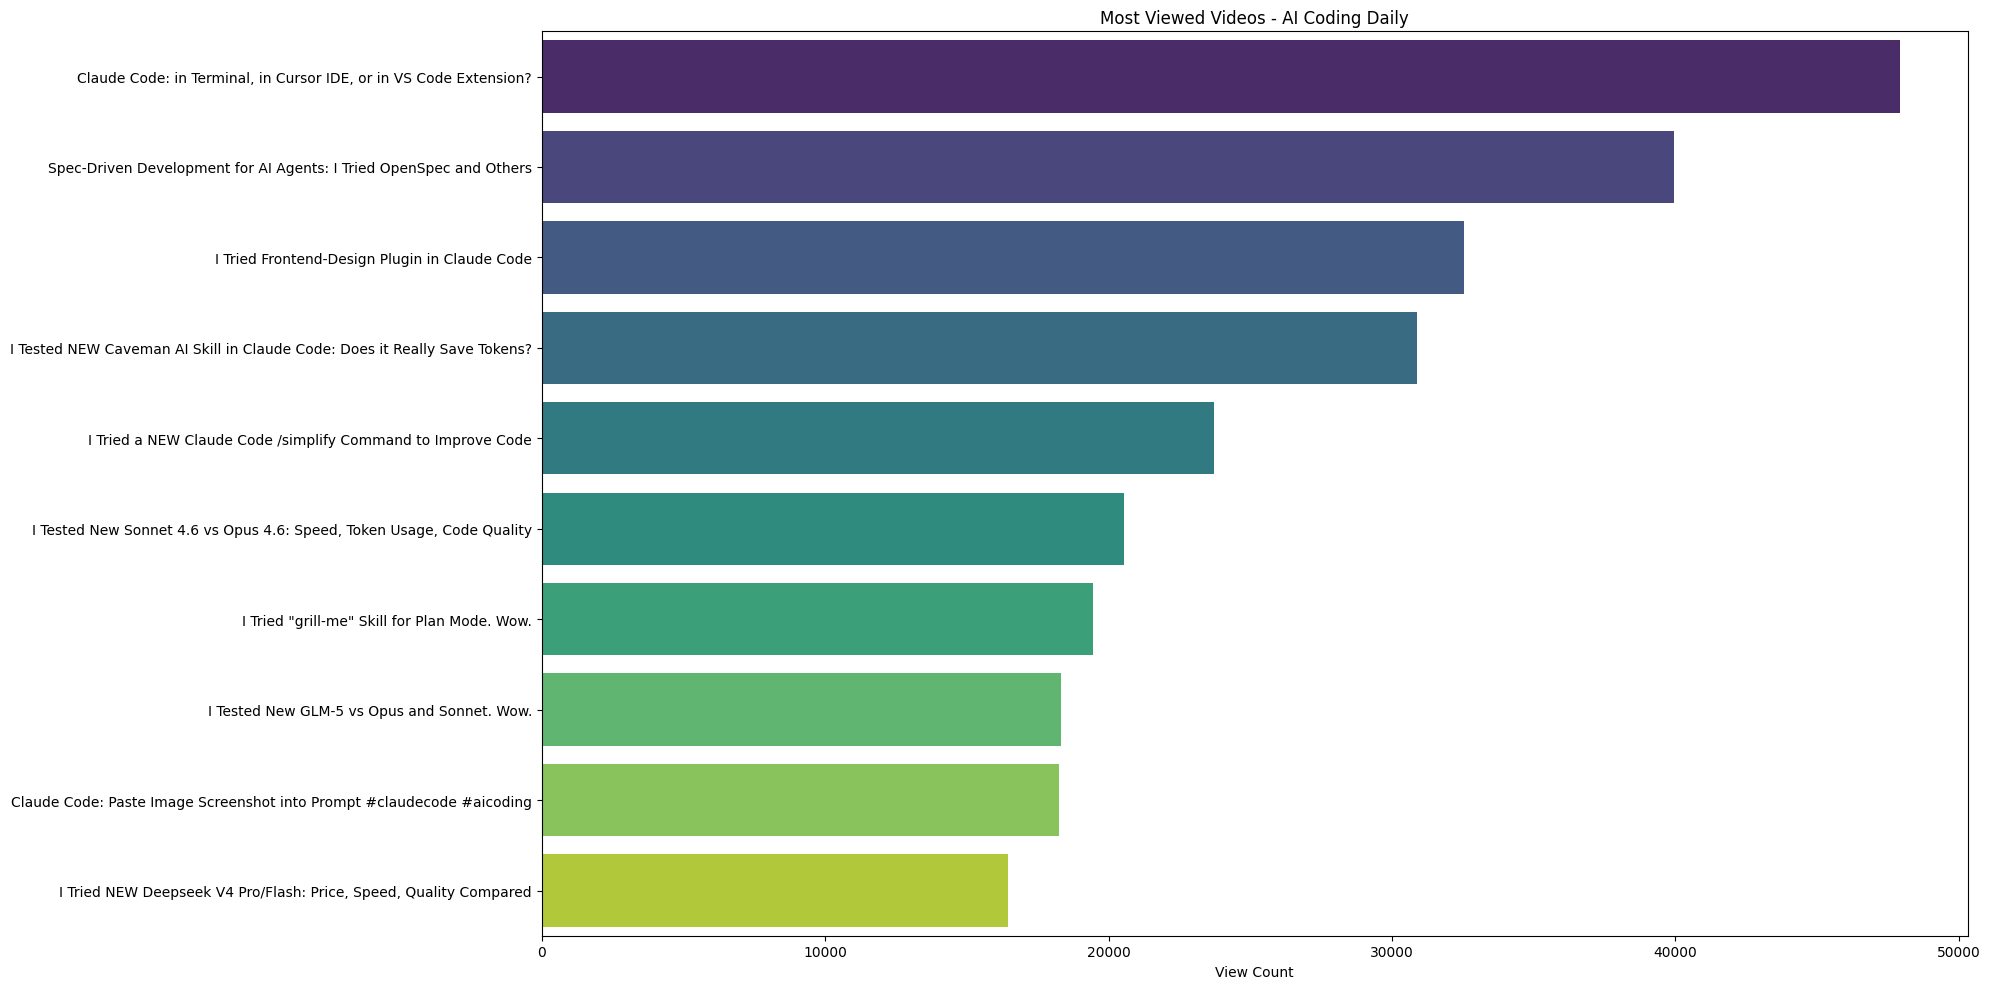

In [40]:
# Cell 15: Visualize Most Viewed Videos
plt.figure(figsize=(20, 10))
plot = sns.barplot(
    x="view_count", 
    y="title", 
    hue="title",  # Add this line
    data=df_highest_views,
    palette="viridis",
    legend=False  # Keep this to hide legend
)
plot.set(xlabel='View Count', ylabel='')
plot.set_title(f'Most Viewed Videos - {channel_stats[0]["snippet"]["title"]}')
plt.tight_layout()
plt.show()

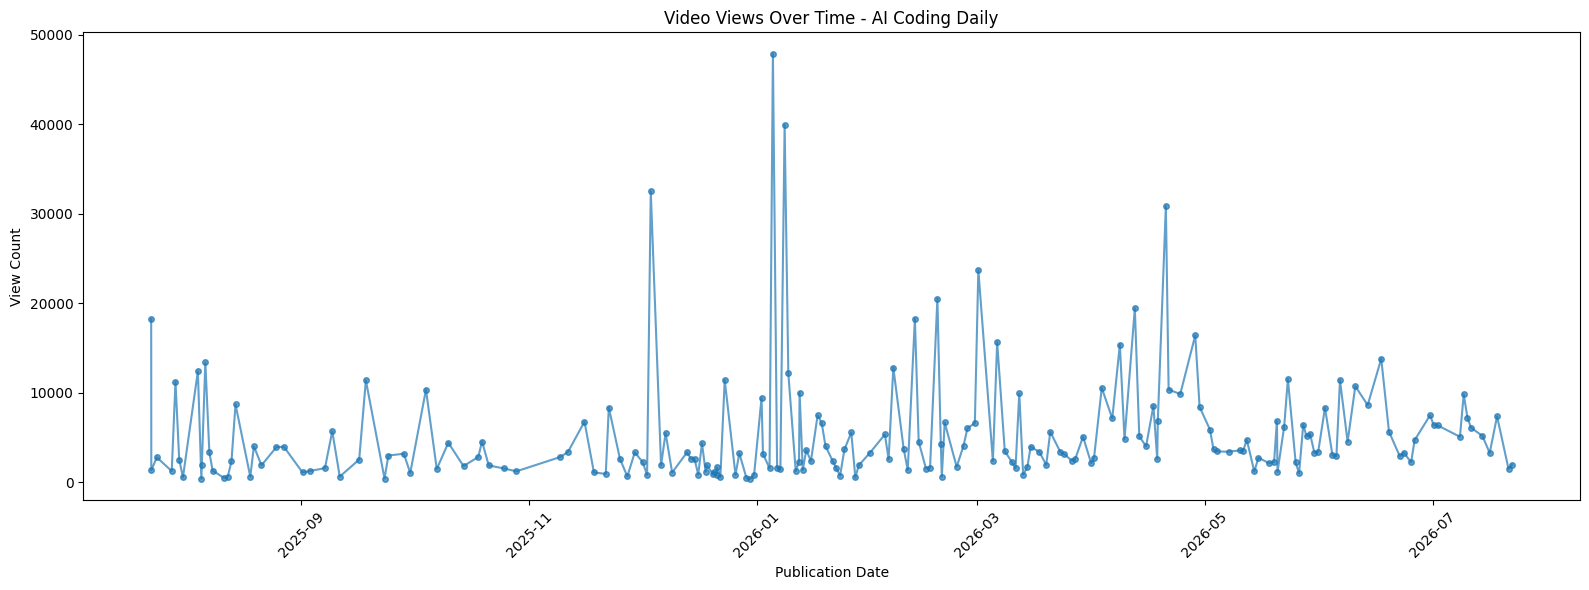

In [42]:
# Cell 16: Visualize Views Over Time
plt.figure(figsize=(16, 6))
plt.plot(df_sorted['published'], df_sorted['view_count'], 'o-', alpha=0.7, markersize=4)
plt.xlabel('Publication Date')
plt.ylabel('View Count')
plt.title(f'Video Views Over Time - {channel_stats[0]["snippet"]["title"]}')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [44]:
# Cell 17: Save to CSV
cols_to_save = ['video_id', 'title', 'published_date', 'view_count', 'hms_format']
output_csv = f"pat_simmons.csv"
df[cols_to_save].to_csv(output_csv, index=False)
print(f"✅ Saved {len(df)} videos to {output_csv}")

✅ Saved 199 videos to pat_simmons.csv


In [46]:
# Cell 18: Save Top Videos to Excel
try:
    import openpyxl
    # Create Excel directory if it doesn't exist
    excel_dir = os.path.join(os.path.dirname(os.getcwd()), "Excel")
    os.makedirs(excel_dir, exist_ok=True)
    xsl_file = os.path.join(excel_dir, "pat_simmons.xlsx")
    
    # Save top 10 videos to Excel
    df_highest_views_copy = df_highest_views.copy()
    df_highest_views_copy['read'] = 'N'
    df_highest_views_copy[cols_to_save + ['read']].to_excel(xsl_file, index=False)
    print(f"✅ Saved top videos to {xsl_file}")
except Exception as e:
    print(f"⚠️ Could not save Excel file: {e}")
    print(f"   Error: {str(e)}")

✅ Saved top videos to C:\Users\User\OneDrive\A4\Excel\pat_simmons.xlsx


In [48]:
# Cell 19: Summary Statistics
print("\n" + "="*60)
print("📊 CHANNEL SUMMARY")
print("="*60)
print(f"Channel Name: {channel_stats[0]['snippet']['title']}")
print(f"Total Videos: {len(df)}")
print(f"Total Views: {df['view_count'].sum():,}")
print(f"Average Views per Video: {df['view_count'].mean():,.0f}")
print(f"Median Views per Video: {df['view_count'].median():,.0f}")
print(f"Total Likes: {df['like_count'].sum():,}")
print(f"Total Comments: {df['comment_count'].sum():,}")
print(f"Most Viewed Video: {df.loc[df['view_count'].idxmax(), 'title'][:60]}... ({df['view_count'].max():,} views)")
print(f"Least Viewed Video: {df.loc[df['view_count'].idxmin(), 'title'][:60]}... ({df['view_count'].min():,} views)")


📊 CHANNEL SUMMARY
Channel Name: AI Coding Daily
Total Videos: 199
Total Views: 1,051,299
Average Views per Video: 5,283
Median Views per Video: 3,331
Total Likes: 26,535
Total Comments: 4,082
Most Viewed Video: Claude Code: in Terminal, in Cursor IDE, or in VS Code Exten... (47,918 views)
Least Viewed Video: Coding Exam Project with AI: Part 8/9 - Taking Quiz and Resu... (403 views)


In [50]:
# Cell 20: Video Length Statistics
print("\n" + "="*60)
print("⏱️ VIDEO LENGTH STATISTICS")
print("="*60)
df['duration_minutes'] = df['duration_seconds'] / 60
print(f"Average Duration: {df['duration_minutes'].mean():.1f} minutes")
print(f"Median Duration: {df['duration_minutes'].median():.1f} minutes")
print(f"Shortest Video: {df['duration_minutes'].min():.1f} minutes")
print(f"Longest Video: {df['duration_minutes'].max():.1f} minutes")


⏱️ VIDEO LENGTH STATISTICS
Average Duration: 9.2 minutes
Median Duration: 8.8 minutes
Shortest Video: 0.7 minutes
Longest Video: 59.2 minutes


In [52]:
# Cell 21: Engagement Metrics
print("\n" + "="*60)
print("💬 ENGAGEMENT METRICS")
print("="*60)
df['like_rate'] = df['like_count'] / df['view_count'] * 100
df['comment_rate'] = df['comment_count'] / df['view_count'] * 100
print(f"Average Like Rate: {df['like_rate'].mean():.2f}%")
print(f"Average Comment Rate: {df['comment_rate'].mean():.2f}%")
print(f"Highest Like Rate: {df['like_rate'].max():.2f}%")
print(f"Highest Like Rate Video: {df.loc[df['like_rate'].idxmax(), 'title'][:60]}...")
print(f"Highest Comment Rate: {df['comment_rate'].max():.2f}%")
print(f"Highest Comment Rate Video: {df.loc[df['comment_rate'].idxmax(), 'title'][:60]}...")


💬 ENGAGEMENT METRICS
Average Like Rate: 3.29%
Average Comment Rate: 0.50%
Highest Like Rate: 8.26%
Highest Like Rate Video: Claude Code Hook: Check Git Status When Running "Claude"...
Highest Comment Rate: 1.87%
Highest Comment Rate Video: The Most Popular AI IDE is... (Poll Results)...


### If want to search specific title

In [54]:
# Cell 22: Find "Claude Design Is ABSURD" - Final Check
print("\n" + "="*60)
print("🔍 SPECIFIC VIDEO SEARCH")
print("="*60)

# Search for the exact video
exact_video = df[df['title'] == "I Tested NEW GLM-5.2 on Four Projects. Wow."]
if not exact_video.empty:
    print("✅ Found 'Claude Design Is ABSURD':")
    display(exact_video[['video_id', 'title', 'published_date', 'view_count', 'like_count', 'comment_count']])
else:
    print("❌ 'Claude Design Is ABSURD' not found in the dataset.")
    print("\nSearching for videos with 'Claude' in the title:")
    claude_videos = df[df['title'].str.contains("Claude", case=False, na=False)]
    if not claude_videos.empty:
        print(f"Found {len(claude_videos)} videos with 'Claude' in the title:")
        display(claude_videos[cols_to_display].head(10))
    else:
        print("No videos with 'Claude' in the title.")


🔍 SPECIFIC VIDEO SEARCH
✅ Found 'Claude Design Is ABSURD':


,video_id,title,published_date,view_count,like_count,comment_count
17,YM2Sk7wEmi0,I Tested NEW GLM-5.2 on Four Projects. Wow.,2026-06-17,13823,416,91



📊 VIDEO DISTRIBUTION BY LENGTH
length_category
Medium (5-15 min)      139
Short (<5 min)          40
Long (15-30 min)        19
Very Long (>30 min)      1
Name: count, dtype: int64


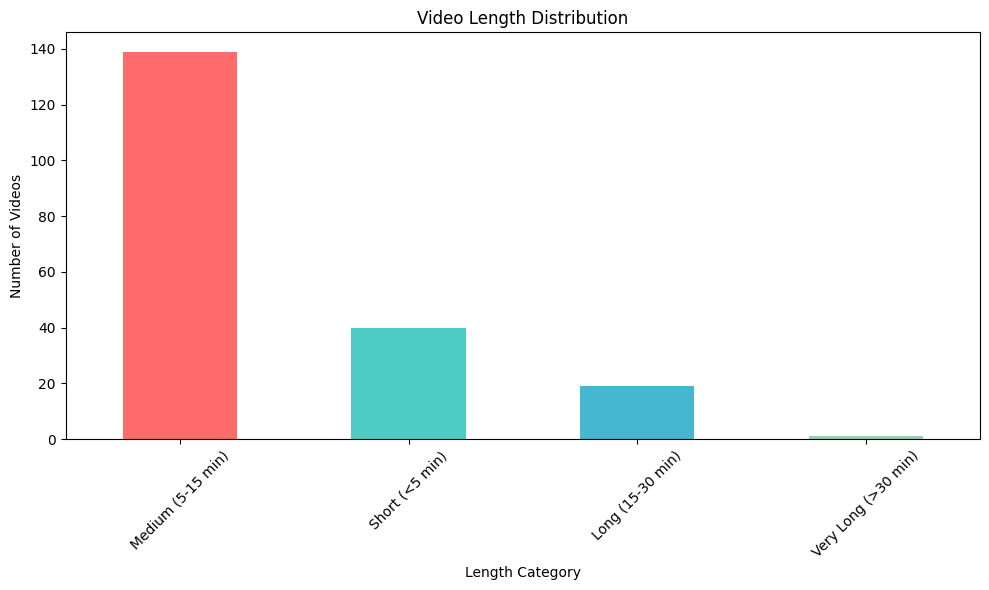

In [56]:
# Cell 23: Additional Analysis - Video Distribution by Length
print("\n" + "="*60)
print("📊 VIDEO DISTRIBUTION BY LENGTH")
print("="*60)

# Categorize videos by length
def categorize_video(minutes):
    if minutes < 5:
        return "Short (<5 min)"
    elif minutes < 15:
        return "Medium (5-15 min)"
    elif minutes < 30:
        return "Long (15-30 min)"
    else:
        return "Very Long (>30 min)"

df['length_category'] = df['duration_minutes'].apply(categorize_video)
length_distribution = df['length_category'].value_counts()
print(length_distribution)

# Visualize length distribution
plt.figure(figsize=(10, 6))
length_distribution.plot(kind='bar', color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
plt.title('Video Length Distribution')
plt.xlabel('Length Category')
plt.ylabel('Number of Videos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


📅 UPLOAD FREQUENCY BY MONTH
year_month
2025-08    15
2025-09    11
2025-10     9
2025-11     9
2025-12    24
2026-01    25
2026-02    17
2026-03    19
2026-04    16
2026-05    22
2026-06    14
2026-07    11
Name: count, dtype: int64


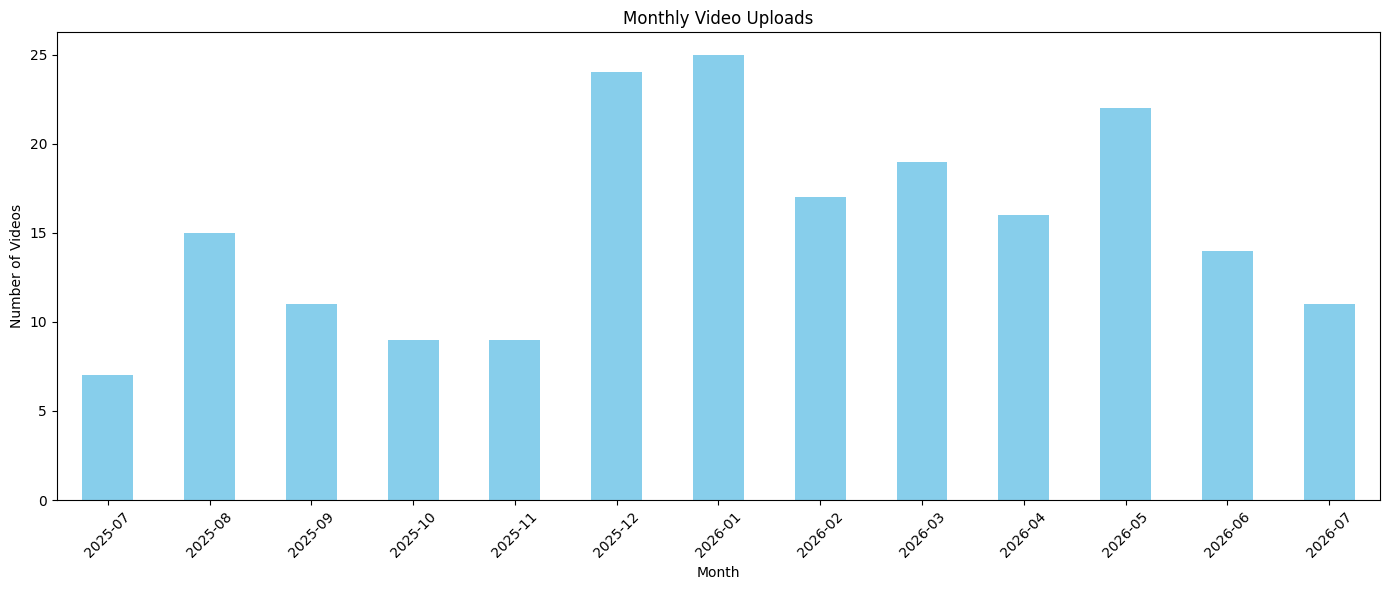


✅ Analysis Complete! All data has been processed and saved.


In [58]:
# Cell 24: Monthly Upload Frequency
print("\n" + "="*60)
print("📅 UPLOAD FREQUENCY BY MONTH")
print("="*60)

df['year_month'] = df['published'].dt.strftime('%Y-%m')
monthly_uploads = df['year_month'].value_counts().sort_index()
print(monthly_uploads.tail(12))  # Show last 12 months

# Visualize upload frequency
plt.figure(figsize=(14, 6))
monthly_uploads.plot(kind='bar', color='skyblue')
plt.title('Monthly Video Uploads')
plt.xlabel('Month')
plt.ylabel('Number of Videos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n✅ Analysis Complete! All data has been processed and saved.")